Import

In [9]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np
from utils.kmeas import fit_kmeans
from utils.codec import encode, decode
from utils.visualization import show_images, plot_latent_space

In [10]:
# Chargement du dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Shapes
print(x_train.shape, y_train.shape)  # (60000, 28, 28), (60000,)
print(x_test.shape, y_test.shape)    # (10000, 28, 28), (10000,)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [11]:
X_train = x_train.astype(np.float32) / 255.0
X_test = x_test.astype(np.float32) / 255.0

X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

print(X_train.dtype)      # float32
print(X_train.min())      # 0.0
print(X_train.max())      # 1.0
print(X_train.shape)      # (60000, 784)

float32
0.0
1.0
(60000, 784)


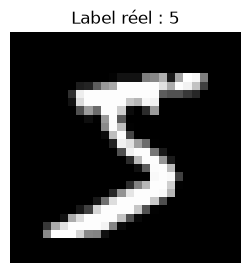

In [12]:
idx = 0

plt.figure(figsize=(3, 3))
plt.imshow(x_train[idx].reshape(28, 28), cmap="gray")
plt.title(f"Label réel : {y_train[idx]}")
plt.axis("off")
plt.show()

In [ ]:
N_DEBUG = 1000
K = 100
MAX_ITER = 1000
TOLERANCE = 1e-4
SEED = 42

X_debug = X_train[:N_DEBUG]

centroids, cluster_labels = fit_kmeans(
    X=X_debug,
    k=K,
    max_iter=MAX_ITER,
    tolerance=TOLERANCE,
    seed=SEED,
    verbose=True
)

Iteration 0: inertia = 14669.5938
Convergence après 5 itérations


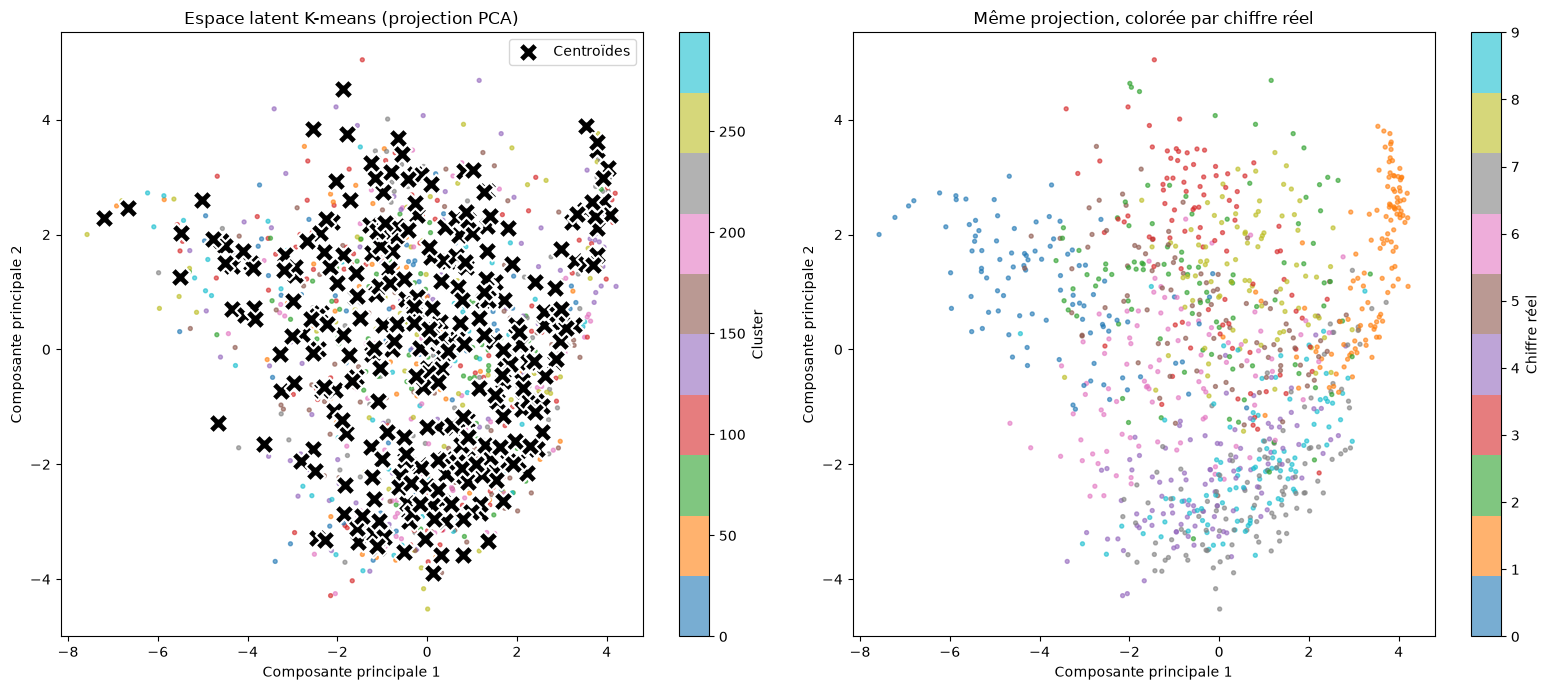

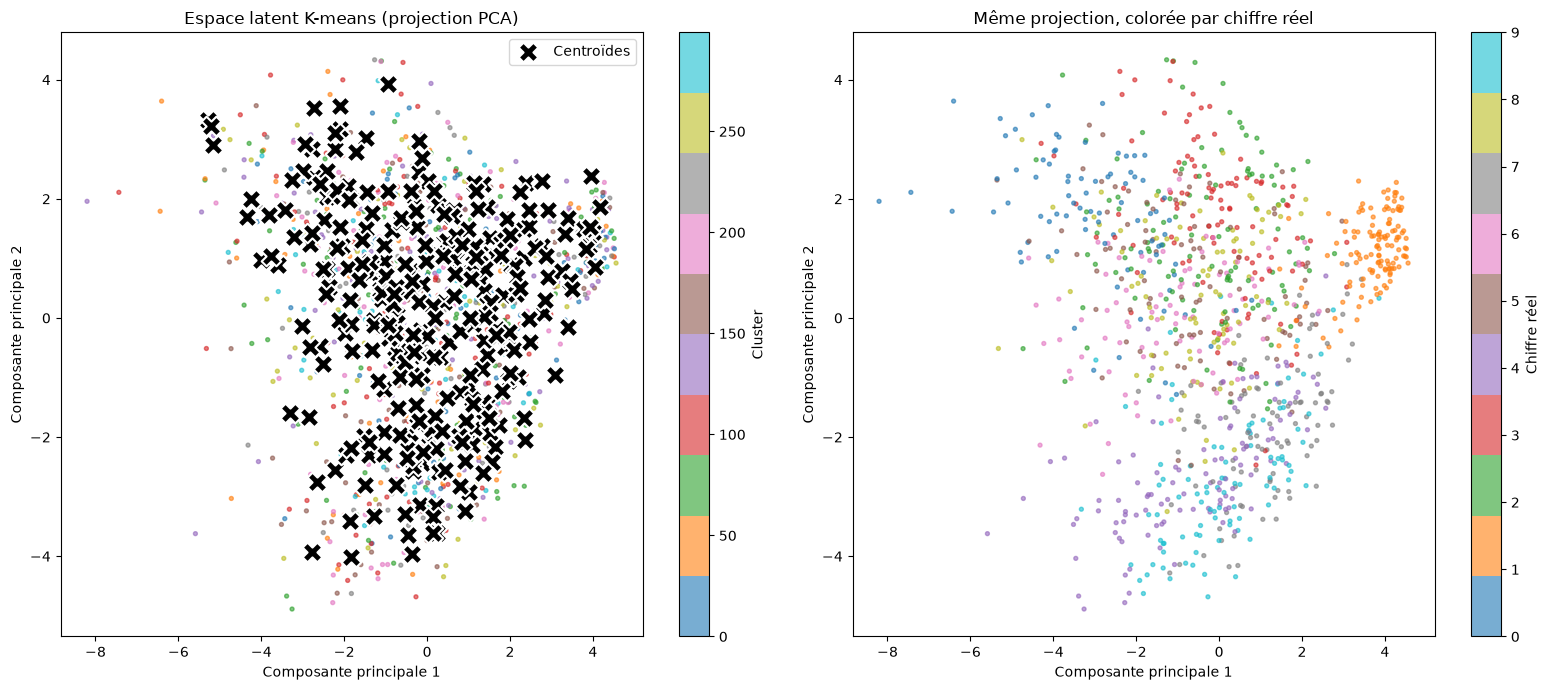

In [14]:
plot_latent_space(X_debug, cluster_labels, centroids, y_train[:N_DEBUG])
plot_latent_space(X_test[:N_DEBUG], cluster_labels, centroids, y_test[:N_DEBUG])

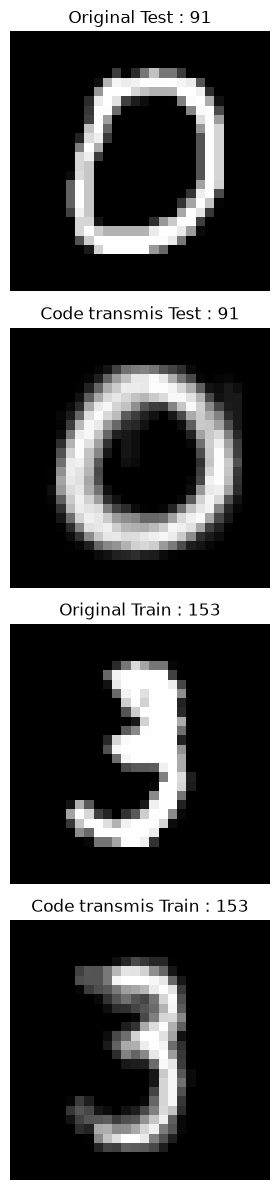

In [16]:
# Test
img_test = X_test[10]
code_test = encode(img_test, centroids)
dec_test = decode(code_test, centroids)

# Train
img_train = X_train[10]
code_train = encode(img_train, centroids)
dec_train = decode(code_train, centroids)

show_images(
    [img_test, dec_test, img_train, dec_train],
    titles=[
        f"Original Test : {int(code_test.numpy())}",
        f"Code transmis Test : {int(code_test.numpy())}",
        f"Original Train : {int(code_train.numpy())}",
        f"Code transmis Train : {int(code_train.numpy())}",
    ],
    n_rows=4, n_cols=1,   # ← 4 images empilées en colonne
)
